In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import pypsa

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/google/cloud/storage/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution
ERROR 1: PROJ: proj_create_from_database: Open of /home/lukas/micromamba/envs/pypsa-eur/share/proj failed


In [41]:
necp = pd.read_csv(
    Path.cwd().parent / 'data' / 'Ember_NECP_data_2024.csv'
).set_index(['SHORT_COUNTRY_CODE', 'FUEL_CODE', 'YEAR', 'KPI'])

In [69]:
tyndp_2030 = pd.read_csv(
    Path.cwd().parent / 'resources' / 'tyndp_capacities_2030.csv', index_col=0, header=[0, 1]
).mul(1e-3)
tyndp_2035 = pd.read_csv(
    Path.cwd().parent / 'resources' / 'tyndp_capacities_2035.csv', index_col=0, header=[0, 1]
).mul(1e-3)

In [149]:
countries = [
    'DE', 'FR', 'GB', 'IT', 'ES', 'PL', 'SE', 'NO', 'NL', 'FI', 'RO', 'GR',
    'PT', 'CZ', 'BE', 'AT', 'BG', 'DK', 'HU', 'IE'# , 'HR', 'LT', 'LV', 'EE'
]
countries

['DE',
 'FR',
 'GB',
 'IT',
 'ES',
 'PL',
 'SE',
 'NO',
 'NL',
 'FI',
 'RO',
 'GR',
 'PT',
 'CZ',
 'BE',
 'AT',
 'BG',
 'DK',
 'HU',
 'IE']

In [150]:
techs = ['onwind', 'offwind', 'solar', 'battery']

In [151]:
idx = pd.IndexSlice

In [152]:
n_2030 = pypsa.Network(Path.cwd().parent / 'results' / 'networks' / 'base_s_50__3H-T-H-B-I-A-dist1_2030_NT+fast_3000.nc')
n_2035 = pypsa.Network(Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2035_NT+fast_endo.nc')

INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2030_NT+fast_3000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2035_NT+fast_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [141]:
def get_model_capacity(n, cc, carrier):
    covered = ['solar', 'onwind', 'offwind', 'battery', 'industry gas', 'gas boiler']
    assert carrier in covered, f"Carrier {carrier} not in covered,\ncovered: {covered}"

    if isinstance(n, str):
        n = pypsa.Network(n)

    if carrier == 'solar':
        gens = n.generators.loc[n.generators.carrier.isin(['solar', 'solar-hsat']) & n.generators.index.str.startswith(cc)]
        return gens['p_nom_opt'].sum() / 1e3 # to GW

    elif carrier == 'onwind':
        gens = n.generators.loc[n.generators.carrier.isin(['onwind']) & n.generators.index.str.startswith(cc)]
        return gens['p_nom_opt'].sum() / 1e3 # to GW

    elif carrier == 'offwind':
        gens = n.generators.loc[n.generators.carrier.isin(['offwind-ac', 'offwind-dc', 'offwind-float']) & n.generators.index.str.startswith(cc)]
        return gens['p_nom_opt'].sum() / 1e3 # to GW

    elif carrier == 'battery':
        links = n.links.loc[n.links.carrier.isin(['battery discharger', 'home battery discharger', 'V2G']) & n.links.index.str.startswith(cc)]
        return links['p_nom_opt'].sum() / 1e3 # to GW

    elif carrier == 'industry gas':
        cs = ['heat100-200 industry gas', 'heat200-500 industry gas', 'heat>500 industry gas']
        l = n.links.index[n.links.carrier.isin(cs) & n.links.index.str.startswith(cc)]
        
        return n.links_t.p0.loc[:, l].mul(n.snapshot_weightings.objective, axis=0).sum().sum() / 1e6

    elif carrier == 'gas boiler':
        l = n.links.index[n.links.carrier.str.contains('gas boiler') & n.links.index.str.startswith(cc)]
        return n.links_t.p0.loc[:, l].sum(axis=1).mul(n.snapshot_weightings['generators']).sum() / 1e6

get_model_capacity(n_2030, 'DE', 'solar')

151.5831744073806

In [153]:
num_households = { # in millions
    'DE': 41.3,
    'FR': 31.7,
    'GB': 28.6,
    'IT': 26.1,
    'ES': 19.4,
    'PL': 14.7,
    'SE': 4.9,
    'NO': 2.65,
    'NL': 8.4,
    'FI': 2.7,
    'RO': 7.1,
    'GR': 4.6,
    'PT': 4.1,
    'CZ': 4.6,
    'BE': 5.2,
    'AT': 4.2,
    'BG': 2.9,
    'DK': 2.9,
    'HU': 4.4,
    'IE': 1.8,
}

# we will assume that share of heat pumps supply times num households is the total number of heat pumps

In [154]:
def get_hp_shares(n, countries):
    heating_demands = ['rural heat', 'urban decentral heat', 'urban central heat']
    
    ss = n.statistics.energy_balance(groupby=['carrier', 'bus_carrier', 'bus'])
    ss = ss.loc[ss > 0.]
    
    hp_shares = pd.Series(np.nan, index=countries)
    
    for c in countries:
        sss = ss.loc[ss.index.get_level_values(3).str.startswith(c)]
        sss = sss.loc[sss.index.get_level_values(2).isin(heating_demands)]
        
        total_supply = sss.sum()
        hp_supply = sss.loc[sss.index.get_level_values(1).str.contains('heat pump')].sum()
        
        hp_share = hp_supply / total_supply
        hp_shares.loc[c] = hp_share
    
    return hp_shares

hp_shares_2030 = get_hp_shares(n_2030, countries)
hp_shares_2035 = get_hp_shares(n_2035, countries)

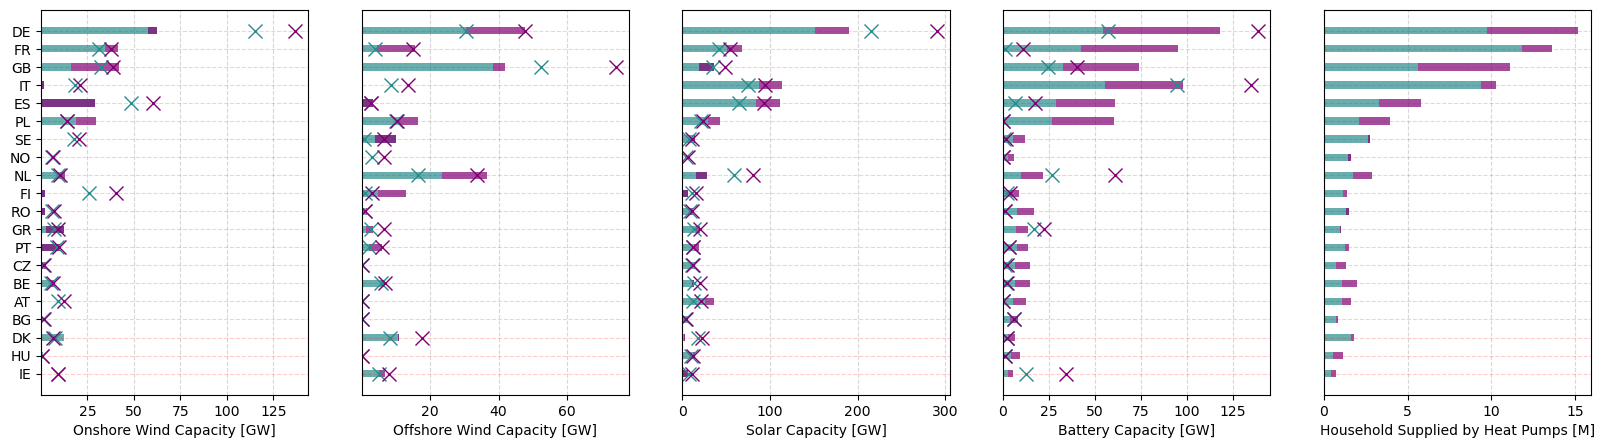

In [171]:
colors = {
    2030: '#298c8c',
    2035: '#800074'
}

fig, axs = plt.subplots(1, len(techs) + 1, figsize=(4*(len(techs) + 1), 5))

for ax, tech in zip(axs, techs):
    
    for i in range(len(countries)):
        ax.axhline(-i, color='r', linestyle='--', alpha=0.2, linewidth=0.8)
        c = countries[i]

        if tech == 'battery':
            value_2030 = tyndp_2030.loc[c, idx[['battery', 'home battery'], 'NT']].sum()
            value_2035 = tyndp_2035.loc[c, idx[['battery', 'home battery'], 'NT']].sum()
        else:
            value_2030 = tyndp_2030.loc[c, (tech, 'NT')]
            value_2035 = tyndp_2035.loc[c, (tech, 'NT')]

        ax.plot(value_2030, -i, marker='x', color=colors[2030], markersize=10)
        ax.plot(value_2035, -i, marker='x', color=colors[2035], markersize=10)

        model_2030 = get_model_capacity(n_2030, c, tech)
        model_2035 = get_model_capacity(n_2035, c, tech)

        ax.barh(-i, model_2030, height=0.4, color=colors[2030], alpha=0.7)
        ax.barh(-i, model_2035 - model_2030, left=model_2030, height=0.4, color=colors[2035], alpha=0.7)
    

ax = axs[-1]
for i in range(len(countries)):

    ax.axhline(-i, color='r', linestyle='--', alpha=0.2, linewidth=0.8)
    c = countries[i]

    # ax.plot(value_2030, -i, marker='x', color='blue', markersize=10)
    # ax.plot(value_2035, -i, marker='x', color='green', markersize=10)

    model_2030 = hp_shares_2030.loc[c] * num_households[c]
    model_2035 = hp_shares_2035.loc[c] * num_households[c]

    ax.barh(-i, model_2030, height=0.4, color=colors[2030], alpha=0.7)
    ax.barh(-i, model_2035 - model_2030, left=model_2030, height=0.4, color=colors[2035], alpha=0.7)


axs[0].set_yticks(range(-len(countries) + 1, 1))
axs[0].set_yticklabels(countries[::-1])

for ax in axs[1:]:
    ax.set_yticks([])

axs[0].set_xlabel('Onshore Wind Capacity [GW]')
axs[1].set_xlabel('Offshore Wind Capacity [GW]')
axs[2].set_xlabel('Solar Capacity [GW]')
axs[3].set_xlabel('Battery Capacity [GW]')
axs[4].set_xlabel('Household Supplied by Heat Pumps [M]')

for ax in axs:
    ax.grid(True, axis='x', alpha=0.5, linestyle='--')
    ax.set_axisbelow(True)

# plt.tight_layout()
plt.show()

In [166]:
model_2030

DE    0.423713
FR    0.670781
GB    0.354632
IT    0.648727
ES    0.308021
PL    0.254727
SE    1.003973
NO    1.121202
NL    0.380005
FI    0.757483
RO    0.379485
GR    0.395290
PT    0.559754
CZ    0.297629
BE    0.371369
AT    0.454502
BG    0.467349
DK    1.019170
HU    0.226218
IE    0.439221
dtype: float64

<Axes: xlabel='snapshot'>

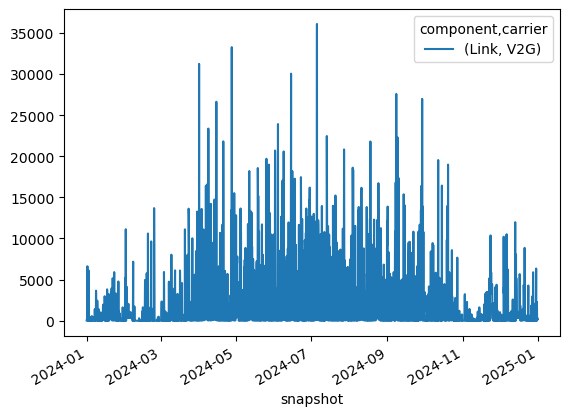

In [143]:
n_2030.statistics.energy_balance(aggregate_time=False).loc[idx[:, :, 'low voltage']].loc[idx[:, 'V2G'], :].T.plot()

DE
FR
GB
IT
ES
PL
SE
NO
NL
FI
RO
GR
PT
CZ
BE
AT
BG
DK
HU
IE
HR
LT
LV
EE


In [147]:
hp_shares

DE    0.358511
FR    0.426173
GB    0.360693
IT    0.436869
ES    0.292153
PL    0.284176
SE    0.487576
NO    0.588509
NL    0.259364
FI    0.430873
RO    0.206923
GR    0.237492
PT    0.383706
CZ    0.347404
BE    0.315334
AT    0.397915
BG    0.398403
DK    0.395672
HU    0.301554
IE    0.348808
HR    0.306983
LT    0.340052
LV    0.275287
EE    0.384235
dtype: float64

In [119]:
pd.Series(households).sort_values()

EE      72400
LV      88900
LT     135300
HR     153600
BG     196800
FI     210700
DK     253600
IE     262000
EL     381500
AT     395100
HU     421100
PT     440400
SE     478600
BE     540800
CZ     559200
RO     729100
NL     758700
PL    1553300
ES    1713700
IT    2117000
FR    3163400
DE    3510400
UK       <NA>
dtype: object